In [1]:
import pandas as pd
from IPython.display import display, Markdown, HTML

from data_processing import *

## Data

In [2]:
# Retrieve all databases
nlexique = pd.read_csv('../data/nlexique.csv')
nlexique = nlexique[['lexeme', 'sg', 'gen']].rename(columns={'sg': 'phon'}).dropna().reset_index(drop=True)

echantinom = pd.read_csv('../data/Echantinom-full-20210902.csv')
echantinom = echantinom[~echantinom['lemma'].isin(nlexique[nlexique['gen'] == 'b']['lexeme'])] #[['lemma', 'phon', 'gen']]

# Working with the regular order 
orth_preds_df = pd.read_csv('../results/echantinom_orth_preds_regular.csv')
orth_preds_df.rename(columns={"Predicted Gender": "orth_pred", "True Gender": "true", "Form": "lemma", "Alt Form": 'phon'}, inplace=True)

phon_preds_df = pd.read_csv('../results/echantinom_phon_preds_regular.csv')
phon_preds_df.rename(columns={"Predicted Gender": "phon_pred", "True Gender": "true", "Form": "phon", "Alt Form": 'lemma'}, inplace=True)


In [ ]:
# Get error rows for each dataset
orth_errors_df = orth_preds_df[orth_preds_df['orth_pred'] != orth_preds_df['true']]
phon_errors_df = phon_preds_df[phon_preds_df['phon_pred'] != phon_preds_df['true']]

# Get the list of lemmas in each dataset
orth_errors_lemmas_list = set(orth_errors_df['lemma'])
phon_errors_lemmas_list  = set(phon_errors_df['lemma'])

# Get error lemmas that are not shared between the two datasets
error_lemma_disagreement_list = orth_errors_lemmas_list.difference(phon_errors_lemmas_list).union(phon_errors_lemmas_list.difference(orth_errors_lemmas_list))

# Concatenate the rows from both datasets where the lemma are not the same
model_disagreement_df = pd.concat([orth_errors_df[orth_errors_df['lemma'].isin(error_lemma_disagreement_list)], phon_errors_df[phon_errors_df['lemma'].isin(error_lemma_disagreement_list)]])
model_disagreement_df.reset_index(drop=True, inplace=True)
model_disagreement_df.rename(columns={'lemma': 'orth'}, inplace=True)
model_disagreement_df.head()

,orth,phon,orth_pred,true,Class Probabilities,Set,suffix,phon_pred
0,obi,Obi,m,f,"[('o', {'f': 0.18929901719093323, 'm': 0.81070...",test,0,NaN
1,son,s2,f,m,"[('s', {'f': 0.07729556411504745, 'm': 0.92270...",test,0,NaN
2,axe,aks,f,m,"[('a', {'f': 0.6409672498703003, 'm': 0.359032...",test,0,NaN
3,bru,bʁy,m,f,"[('b', {'f': 0.1552123725414276, 'm': 0.844787...",test,0,NaN
4,clé,kle,m,f,"[('c', {'f': 0.18727333843708038, 'm': 0.81272...",test,0,NaN


In [4]:
print(f"There are {len(model_disagreement_df)} errors")
print(f"- {len(model_disagreement_df[model_disagreement_df['phon_pred'].isna()])} from the orthographic model")
print(f"- {len(model_disagreement_df[model_disagreement_df['orth_pred'].isna()])} from the phonological model")

There are 767 errors
- 166 from the orthographic model
- 601 from the phonological model


## Analysis

### Compare the initial and final n-gram distribution in errors

In [5]:
def extract_edge_ngrams(df, column='phon', n_values=[1, 2, 3]):
    pred_col = f'{column}_pred'
    
    for n in n_values:
        init_col = f'{column}_init_{n}'
        final_col = f'{column}_final_{n}'

        def get_init(x, pred):
            if pd.isna(pred):
                return float('nan')
            return x[:n] if len(x) >= n else x

        def get_final(x, pred):
            if pd.isna(pred):
                return float('nan')
            return x[-n:] if len(x) >= n else x

        df[init_col] = df.apply(lambda row: get_init(row[column], row[pred_col]), axis=1)
        df[final_col] = df.apply(lambda row: get_final(row[column], row[pred_col]), axis=1)
        
    return df


In [6]:
# Extract edge n-grams
model_disagreement_df = extract_edge_ngrams(model_disagreement_df, column='orth')
model_disagreement_df = extract_edge_ngrams(model_disagreement_df, column='phon')

model_disagreement_df.head()

,orth,phon,orth_pred,true,Class Probabilities,Set,suffix,phon_pred,orth_init_1,orth_final_1,orth_init_2,orth_final_2,orth_init_3,orth_final_3,phon_init_1,phon_final_1,phon_init_2,phon_final_2,phon_init_3,phon_final_3
0,obi,Obi,m,f,"[('o', {'f': 0.18929901719093323, 'm': 0.81070...",test,0,NaN,o,i,ob,bi,obi,obi,NaN,NaN,NaN,NaN,NaN,NaN
1,son,s2,f,m,"[('s', {'f': 0.07729556411504745, 'm': 0.92270...",test,0,NaN,s,n,so,on,son,son,NaN,NaN,NaN,NaN,NaN,NaN
2,axe,aks,f,m,"[('a', {'f': 0.6409672498703003, 'm': 0.359032...",test,0,NaN,a,e,ax,xe,axe,axe,NaN,NaN,NaN,NaN,NaN,NaN
3,bru,bʁy,m,f,"[('b', {'f': 0.1552123725414276, 'm': 0.844787...",test,0,NaN,b,u,br,ru,bru,bru,NaN,NaN,NaN,NaN,NaN,NaN
4,clé,kle,m,f,"[('c', {'f': 0.18727333843708038, 'm': 0.81272...",test,0,NaN,c,é,cl,lé,clé,clé,NaN,NaN,NaN,NaN,NaN,NaN


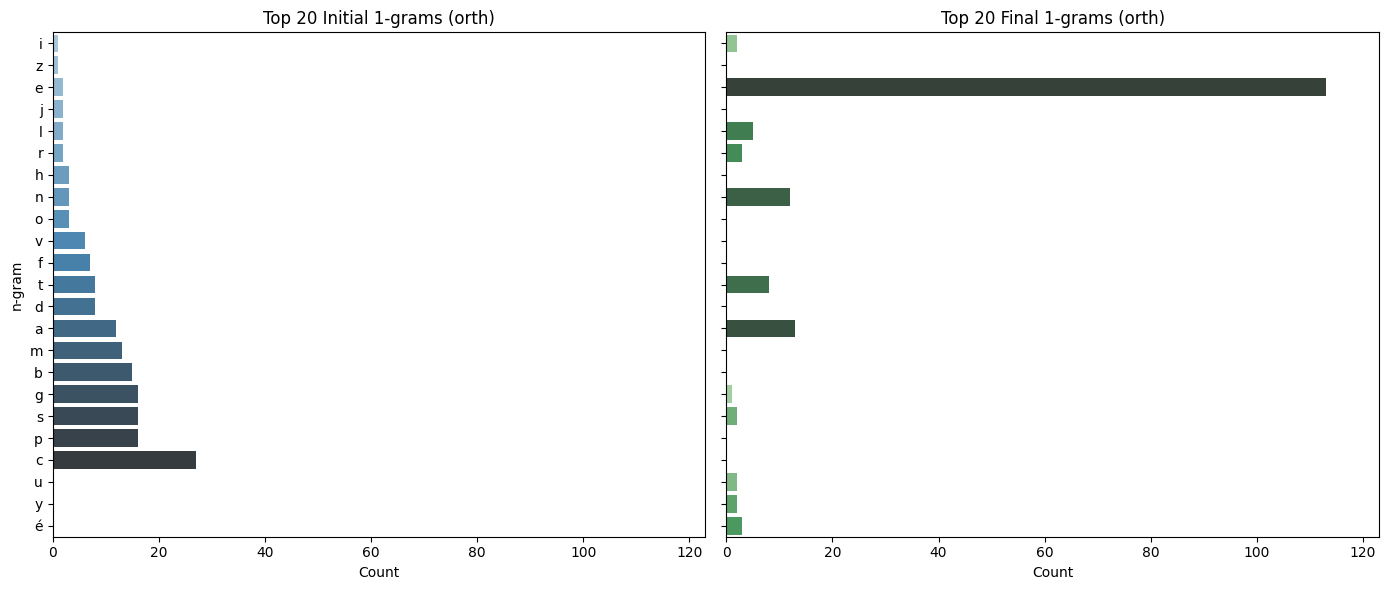

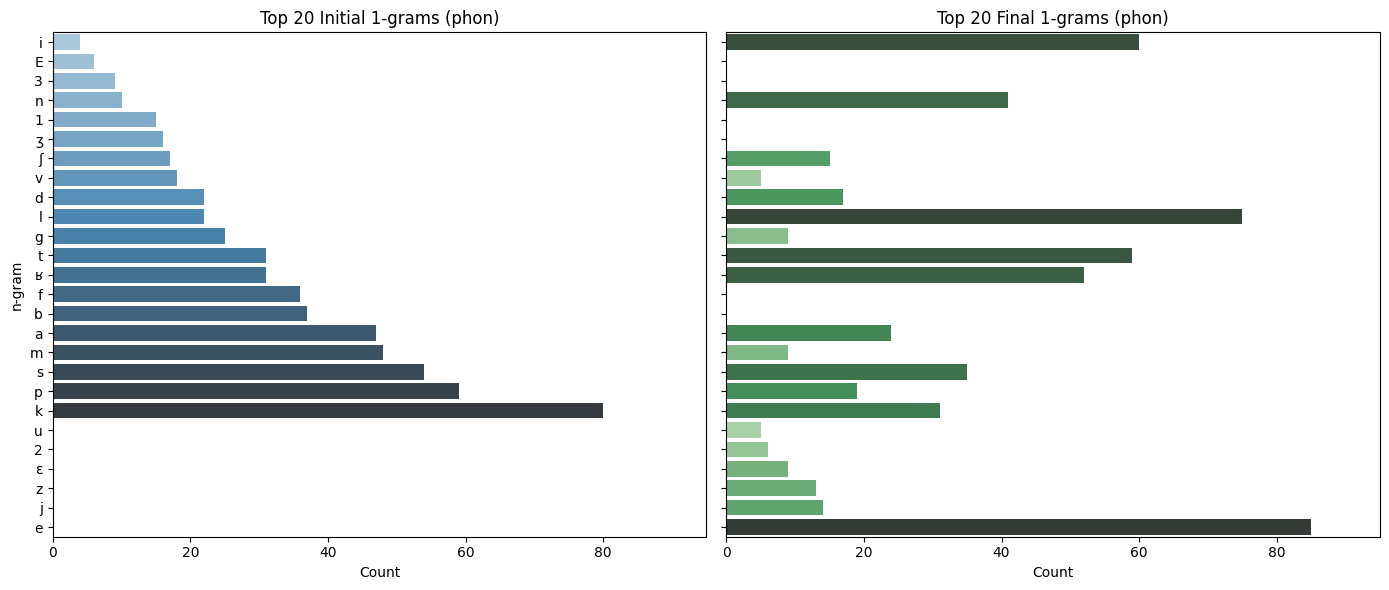

In [7]:
# Compare 1-grams
compare_initial_final_ngrams(model_disagreement_df, column='orth', n_values=[1])
compare_initial_final_ngrams(model_disagreement_df, column='phon', n_values=[1])


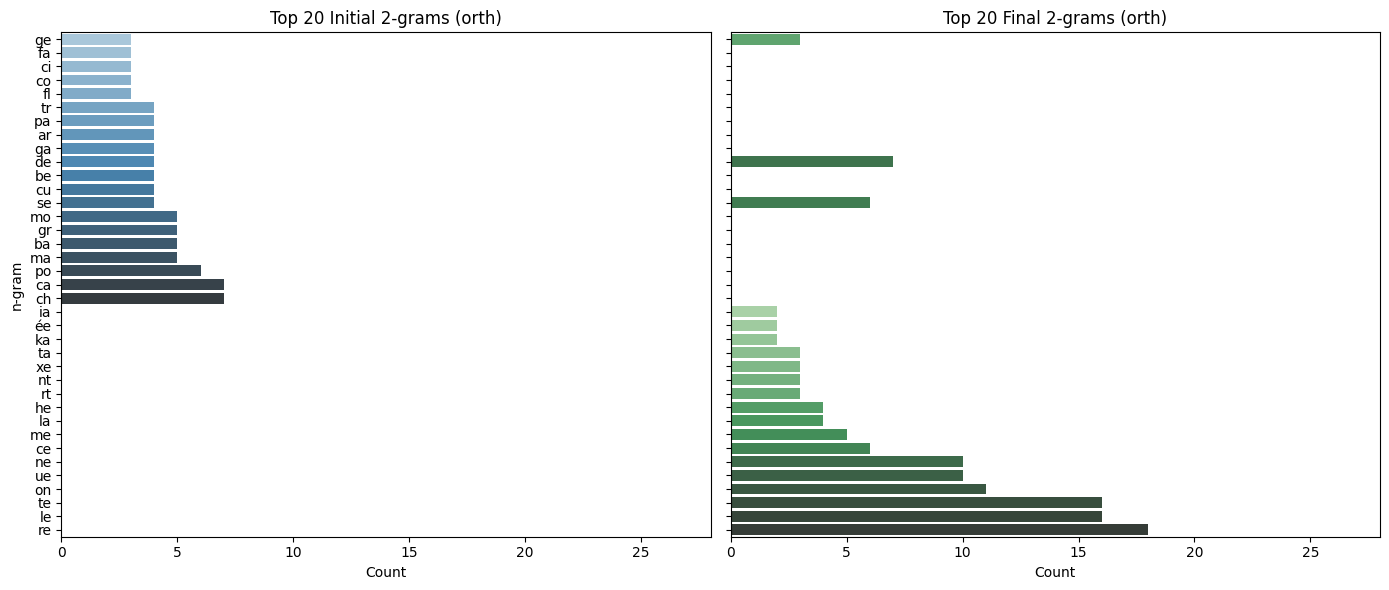

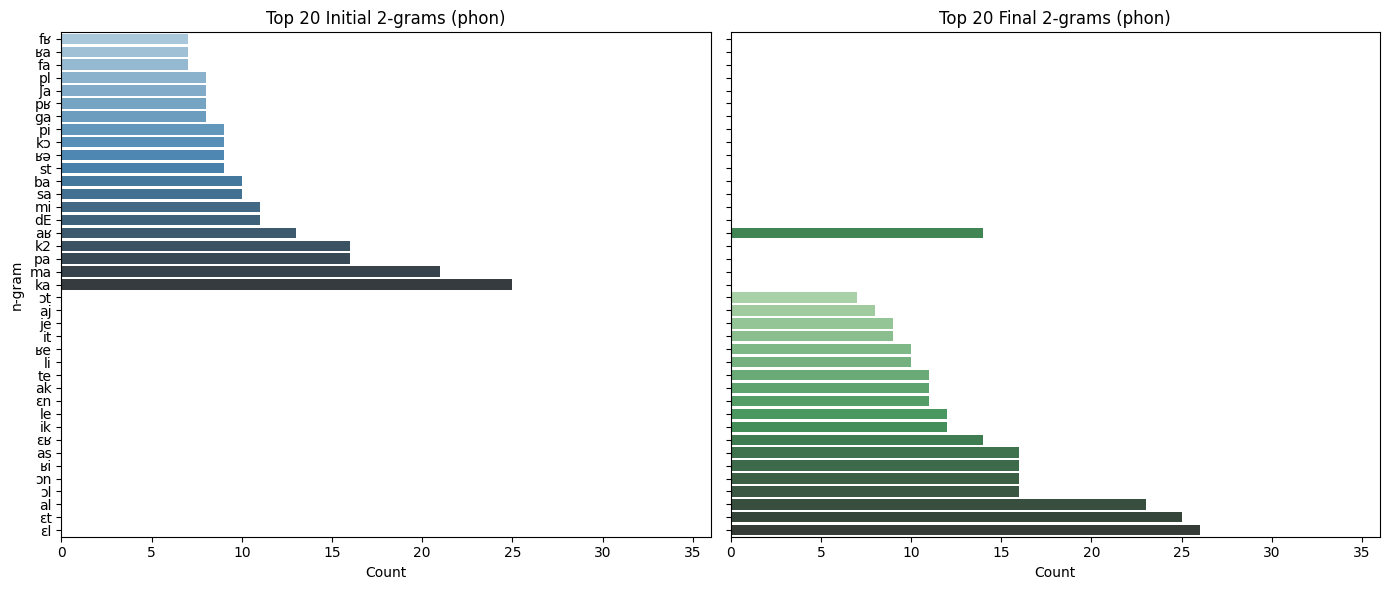

In [8]:
# Compare 2-grams
compare_initial_final_ngrams(model_disagreement_df, column='orth', n_values=[2])
compare_initial_final_ngrams(model_disagreement_df, column='phon', n_values=[2])

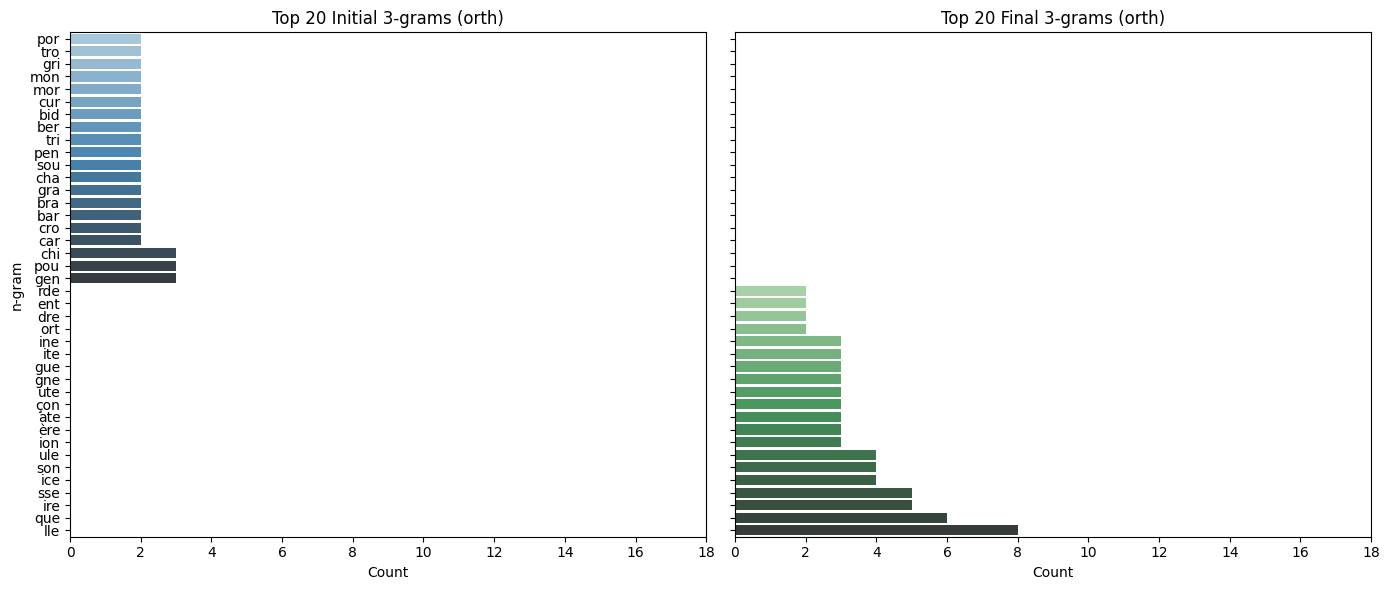

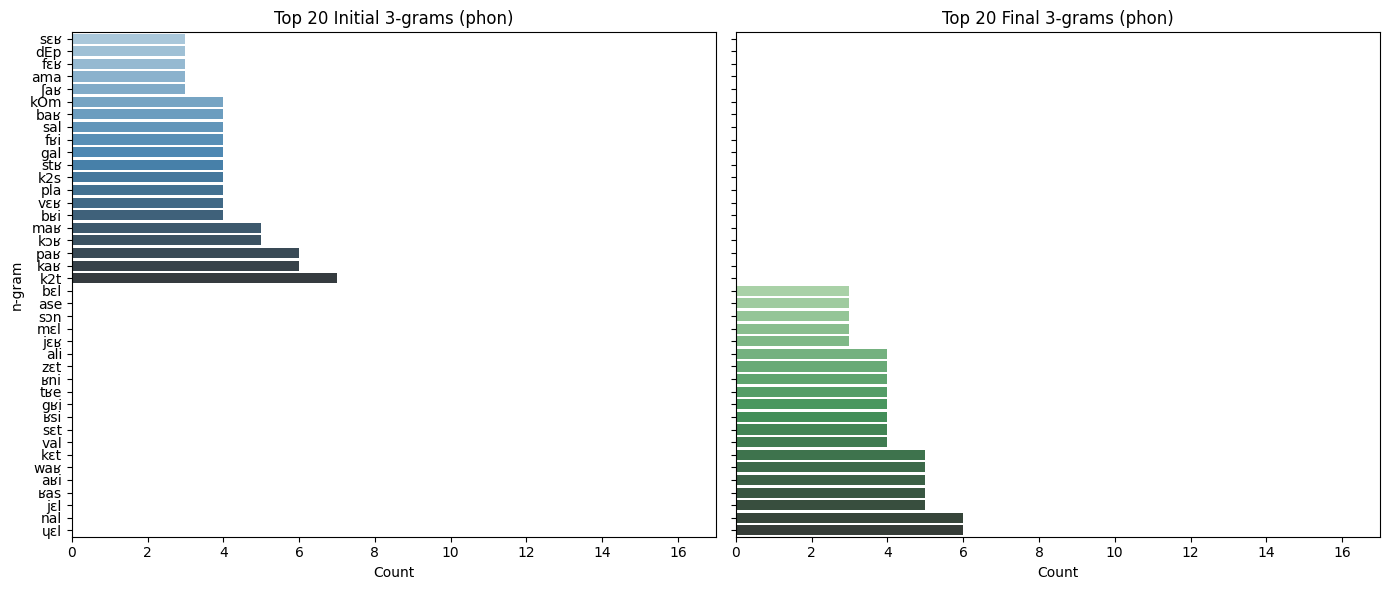

In [9]:
# Compare 3-grams
compare_initial_final_ngrams(model_disagreement_df, column='orth', n_values=[3])
compare_initial_final_ngrams(model_disagreement_df, column='phon', n_values=[3])

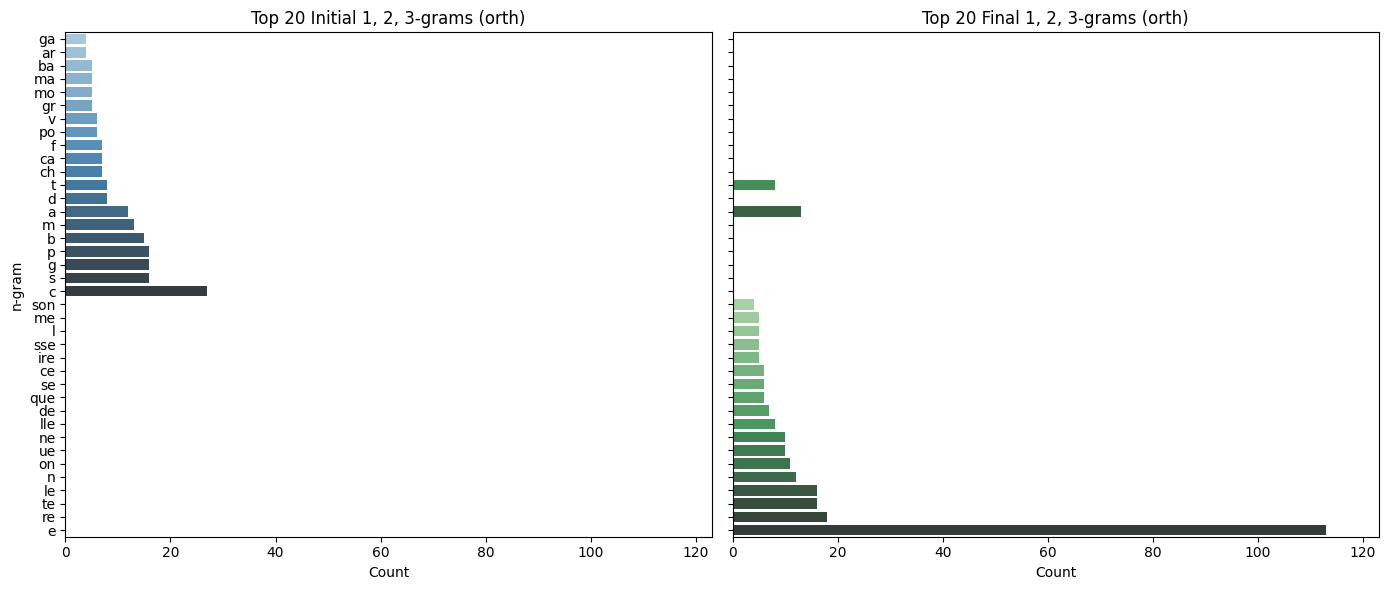

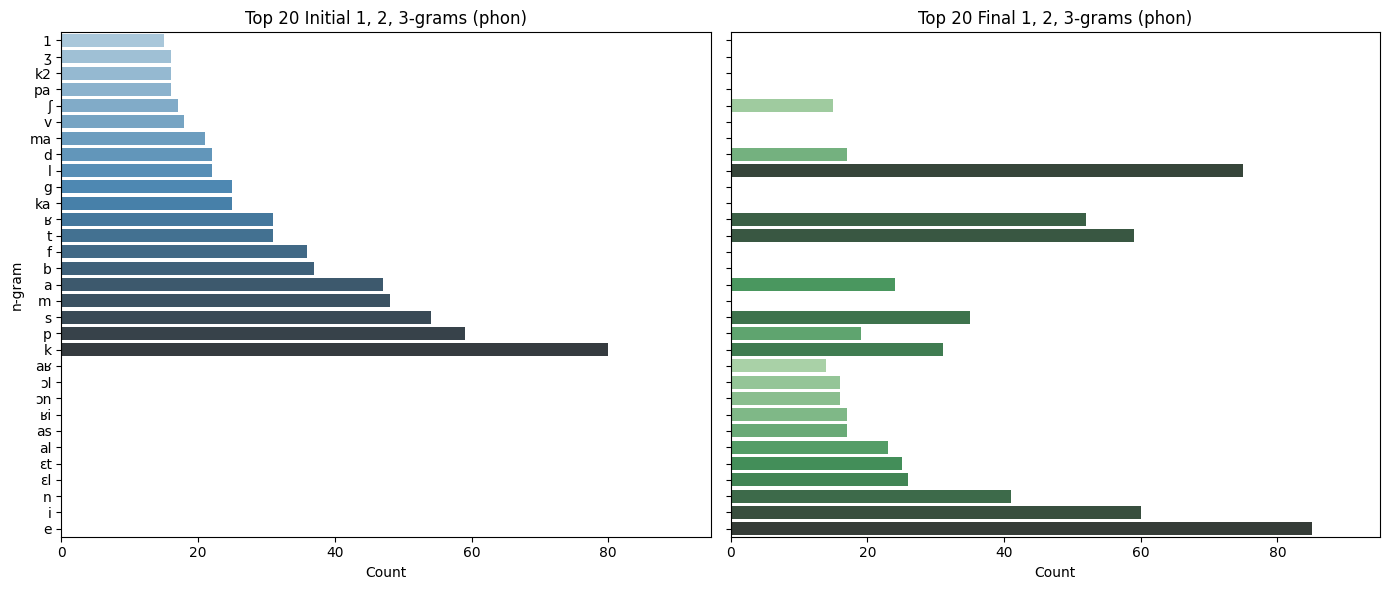

In [10]:
# All
compare_initial_final_ngrams(model_disagreement_df, column='orth', n_values=[1, 2, 3])
compare_initial_final_ngrams(model_disagreement_df, column='phon', n_values=[1, 2, 3])

### Compare these results with the distribution across the whole lexique

In [12]:
def extract_edge_ngrams(df, column='phon', n_values=[1, 2, 3]):
    """
    Adds columns for initial and final n-grams of sizes specified in `n_values` 
    for the selected form ('orthographic' or 'phonemic').
    """
    for n in n_values:
        df[f'{column}_init_{n}'] = df[column].apply(lambda x: x[:n] if len(x) >= n else x)
        df[f'{column}_final_{n}'] = df[column].apply(lambda x: x[-n:] if len(x) >= n else x)
    return df

In [13]:
# Compute general lexicon ngrams
nlexique.rename(columns={'lexeme': 'orth'}, inplace=True)
nlexique_df = extract_edge_ngrams(nlexique, column='orth')
nlexique_df = extract_edge_ngrams(nlexique, column='phon')

# Calculate frequencies for n-grams in the lexique
orth_ngram_freq = calculate_ngram_frequencies(nlexique_df, column_prefix='orth')
phon_ngram_freq = calculate_ngram_frequencies(nlexique_df, column_prefix='phon')

nlexique_df.head()

,orth,phon,gen,orth_init_1,orth_final_1,orth_init_2,orth_final_2,orth_init_3,orth_final_3,phon_init_1,phon_final_1,phon_init_2,phon_final_2,phon_init_3,phon_final_3
0,à-côté,akOte,m,à,é,à-,té,à-c,ôté,a,e,ak,te,akO,Ote
1,à-coup,aku,m,à,p,à-,up,à-c,oup,a,u,ak,ku,aku,aku
2,à-peu-près,apØpʁɛ,m,à,s,à-,ès,à-p,rès,a,ɛ,ap,ʁɛ,apØ,pʁɛ
3,à-pic,apik,m,à,c,à-,ic,à-p,pic,a,k,ap,ik,api,pik
4,à-plat,apla,m,à,t,à-,at,à-p,lat,a,a,ap,la,apl,pla


In [14]:
# Orthographic intial 1-grams
get_ngram_comparison(model_disagreement_df, orth_ngram_freq, direction = 'init', column='orth', n_values=[1])

,count,lexicon_frequency,proportion
i,1,997,0.00
z,1,85,0.01
e,2,1121,0.00
j,2,309,0.01
l,2,926,0.00
r,2,1752,0.00
h,3,746,0.00
n,3,627,0.00
o,3,583,0.01
v,6,749,0.01


In [15]:
# Orthographic final 1-grams
get_ngram_comparison(model_disagreement_df, orth_ngram_freq, direction = 'final', column='orth', n_values=[1])

,count,lexicon_frequency,proportion
g,1,181,0.01
i,2,437,0.00
u,2,519,0.00
s,2,1014,0.00
y,2,101,0.02
é,3,1397,0.00
r,3,2904,0.00
l,5,615,0.01
t,8,2784,0.00
n,12,3687,0.00


In [16]:
# Orthographic intial 2-grams
get_ngram_comparison(model_disagreement_df, orth_ngram_freq, direction = 'init', column='orth', n_values=[2])

,count,lexicon_frequency,proportion
ge,3,79,0.04
fa,3,232,0.01
ci,3,148,0.02
co,3,1339,0.00
fl,3,150,0.02
tr,4,511,0.01
pa,4,649,0.01
ar,4,307,0.01
ga,4,296,0.01
de,4,267,0.01


In [17]:
# Orthographic final 2-grams
get_ngram_comparison(model_disagreement_df, orth_ngram_freq, direction = 'final', column='orth', n_values=[2])


,count,lexicon_frequency,proportion
ia,2,78,0.03
ée,2,509,0.00
ka,2,27,0.07
ta,3,52,0.06
xe,3,22,0.14
nt,3,1550,0.00
rt,3,89,0.03
ge,3,1061,0.00
he,4,354,0.01
la,4,59,0.07


In [18]:
# Orthographic initial 3-grams
get_ngram_comparison(model_disagreement_df, orth_ngram_freq, direction = 'init', column='orth', n_values=[3])


,count,lexicon_frequency,proportion
por,2,103,0.02
tro,2,89,0.02
gri,2,77,0.03
mon,2,110,0.02
mor,2,73,0.03
cur,2,30,0.07
bid,2,10,0.20
ber,2,41,0.05
tri,2,125,0.02
pen,2,45,0.04


In [19]:
# Orthographic final 2-grams
get_ngram_comparison(model_disagreement_df, orth_ngram_freq, direction = 'final', column='orth', n_values=[3])


,count,lexicon_frequency,proportion
rde,2,100,0.02
ent,2,1132,0.00
dre,2,43,0.05
ort,2,43,0.05
ine,3,523,0.01
ite,3,224,0.01
gue,3,177,0.02
gne,3,62,0.05
ute,3,69,0.04
çon,3,30,0.10
